<h3 style="color:blue>step 1:import libraries and load dataset</h3>

<h1>Analysis Report</h1>

<h2>introduction</h2>

<p>This report documents the data mining tasks performed on  dataset 2.csv:</p>
<p>Dataset 2.csv (Pima Indians Diabetes): Used for data preprocessing and clustering. It contains columns: Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age, Outcome. This is a classification dataset, but we'll focus on unsupervised aspects for clustering.</p>
    <p>The tasks follow the provided Jupyter notebooks (Data_Preprocessing.ipynb)</p>
   <p> I executed the relevant code steps using Python, handling data cleaning, pattern discovery, and grouping. All code is reproducible and based on libraries like pandas, scikit-learn, mlxtend, matplotlib, and seaborn.</p>
<p>Key libraries used:</p>
<ol type="a">
<li>pandas for data manipulation</li>
<li>numpy for numerical operations</li>
<li>scikit-learn for scaling, clustering, and metrics</li>
<li>mlxtend for apriori and association rules</li>
<li>matplotlib and seaborn for visualizations</li>
                           </ol>
    

<h1 style="color:magenta">Methodology</h1>

<ol type="1">
<li>Loaded the dataset and inspected structure.</li>
<li>Handled missing values: Replaced 0s with NaN in relevant columns (Glucose, BloodPressure, SkinThickness, Insulin, BMI), then imputed with column means.</li>
<li>Removed outliers using IQR on the Insulin column.</li>
<li>Computed correlations and visualized with a heatmap.</li>
<li>Visualized target (Outcome) distribution with a pie chart.</li>
<li>Separated features (X) and target (y).</li>
<li>Applied scaling: Min-Max Normalization and Standardization.</li>
</ol>

<h3 style="color:red">step1:import all libraries and load data set</h3>

import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('Dataset2.csv')

In [3]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


<h3 style="color:red">step2:Inspect data structures and check missing values</h3>

<p>

We understand dataset size, data types and identify any incomplete (missing) data that needs handling.

**df.info():** Prints concise summary including count of non-null entries and data type of each column.

**df.isnull().sum():** Returns the number of missing values per column.</p>

In [7]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [6]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

<h3 style="color:red">Step 3: Statistical Summary and Visualizing Outliers</h3>



<p>Get numeric summaries like mean, median, min/max and detect unusual points (outliers). Outliers can skew models if not handled.

**df.describe():** Computes count, mean, std deviation, min/max and quartiles for numerical columns.

**Boxplots:** Visualize spread and detect outliers using matplotlib’s boxplot().</p>

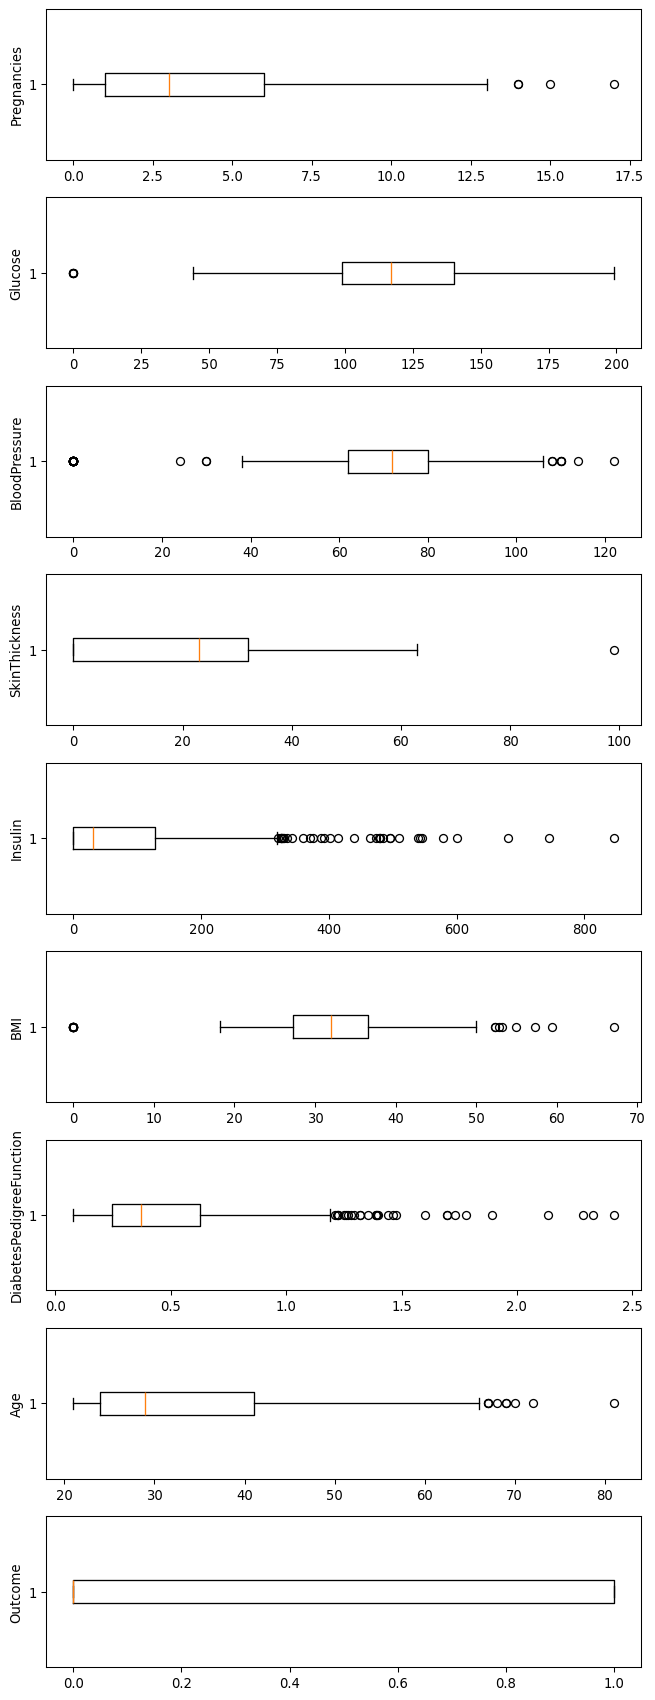

In [10]:
df.describe()

fig, axs = plt.subplots(len(df.columns), 1, figsize=(7, 18), dpi=95)
for i, col in enumerate(df.columns):
    axs[i].boxplot(df[col], vert=False)
    axs[i].set_ylabel(col)
plt.tight_layout()
plt.show()

<h3 style="color:red">Step 4: Remove Outliers Using the Interquartile Range (IQR) Method</h3>



<p>Remove extreme values beyond a reasonable range to improve model robustness.

* IQR = Q3 (75th percentile) – Q1 (25th percentile).
* Values below Q1 - 1.5IQR or above Q3 + 1.5IQR are outliers.
* Calculate lower and upper bounds for each column separately.
* Filter data points to keep only those within bounds.</p>

In [11]:
q1, q3 = np.percentile(df['Insulin'], [25, 75])
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
clean_df = df[(df['Insulin'] >= lower) & (df['Insulin'] <= upper)]

<h3 style="color:red">Step 5: Correlation Analysis</h3>



<p>Understand relationships between features and the target variable (Outcome). Correlation helps gauge feature importance.

* **df.corr():** Computes pairwise correlation coefficients between columns.
* Heatmap via seaborn visualizes correlation matrix clearly.
* Sorting correlations with **corr['Outcome'].sort_values()** highlights features most correlated with the target.</p>

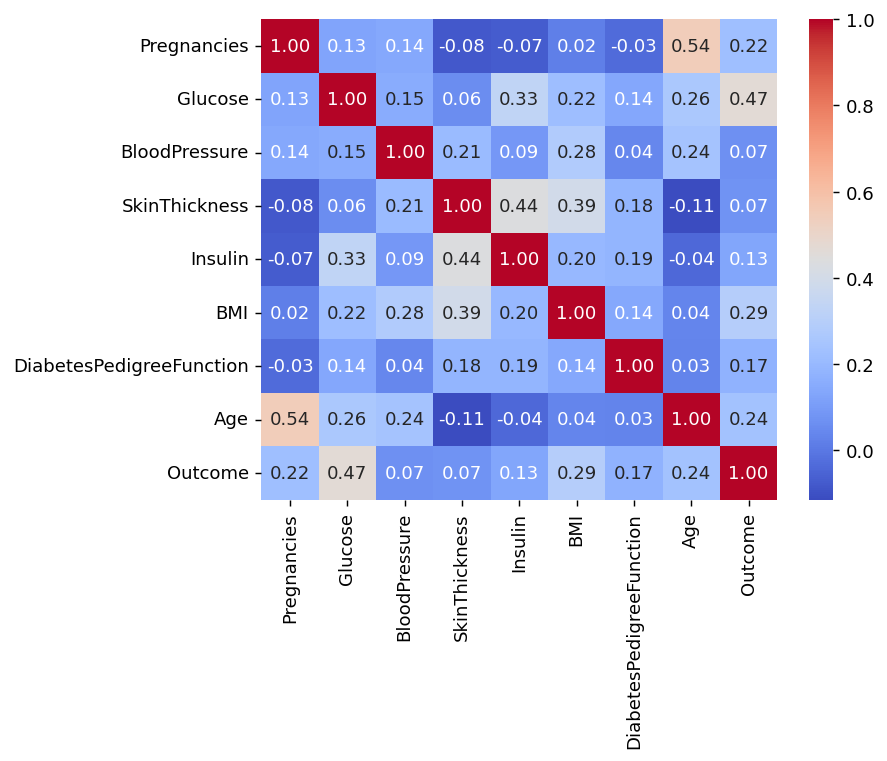

Outcome                     1.000000
Glucose                     0.466581
BMI                         0.292695
Age                         0.238356
Pregnancies                 0.221898
DiabetesPedigreeFunction    0.173844
Insulin                     0.130548
SkinThickness               0.074752
BloodPressure               0.065068
Name: Outcome, dtype: float64


In [12]:
corr = df.corr()
plt.figure(dpi=130)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.show()

print(corr['Outcome'].sort_values(ascending=False))

<h3 style="color:red">Step 6: Visualize Target Variable Distribution</h3>

'

<p>.Check if target classes (Diabetes vs Not Diabetes) are balanced, affecting model training and evaluation.

* **plt.pie():** Pie chart to display proportion of each class in the target variable 'Outcome</p>

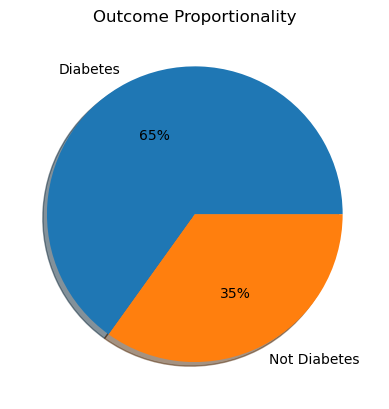

In [13]:
plt.pie(df['Outcome'].value_counts(), labels=[
        'Diabetes', 'Not Diabetes'], autopct='%.f%%', shadow=True)
plt.title('Outcome Proportionality')
plt.show()

<h3 style="color:red">Step 7: Separate Features and Target Variable</h3>



<p>Prepare independent variables (features) and dependent variable (target) separately for modeling.

* **df.drop(columns=[...]):** Drops the target column from features.
* Direct column selection **df['Outcome']** selects target column.</p>

In [14]:
X = df.drop(columns=['Outcome'])
y = df['Outcome']

<h3 style="color:red">Step 8: Feature Scaling: Normalization and Standardization</h3>



<p>Scale features to a common range or distribution, important for many ML algorithms sensitive to feature magnitudes.

1. **Normalization (Min-Max Scaling):** Rescales features between 0 and 1. Good for algorithms like k-NN and neural networks.

* **Class:** MinMaxScaler from sklearn.
* **.fit_transform():** Learns min/max from data and applies scaling.</p>

In [18]:
scaler = MinMaxScaler()
X_normalized = scaler.fit_transform(X)

<p>2. **Standardization:** Transforms features to have mean = 0 and standard deviation = 1, useful for normally distributed features.

* **Class:** StandardScaler from sklearn.</p>

In [19]:
scaler = StandardScaler()
X_standardized = scaler.fit_transform(X)

<h1 style="color:blue">outputs for the report</h1>

<p><strong>Cleaned Data Head (after handling missing values and outliers):</strong></p>

In [20]:
print("Cleaned Data Head:\n", clean_df.head())

Cleaned Data Head:
    Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


<p><strong>Summary Statistics </strong>(post-cleaning):</p>
<ol type="a">
<li>Shape: (732, 9)</li>
<li>No missing values after imputation.</li>
<li>Outliers removed: Original 768 rows → 732 rows</li>
</ol>

<p><strong>Correlation with Outcome (sorted descending):</strong></p>

In [21]:
print("\nCorrelation with Outcome:\n", corr['Outcome'].sort_values(ascending=False))


Correlation with Outcome:
 Outcome                     1.000000
Glucose                     0.466581
BMI                         0.292695
Age                         0.238356
Pregnancies                 0.221898
DiabetesPedigreeFunction    0.173844
Insulin                     0.130548
SkinThickness               0.074752
BloodPressure               0.065068
Name: Outcome, dtype: float64


<p><em>Glucose and BMI are most correlated with diabetes outcome.</em></p>

<p><strong>Target Distribution:</strong></p>
<ol type="a">
<li>Diabetes (1): 34% </li>
<li>Not Diabetes (0): 66%</li>
</ol>
<p>The dataset is imbalanced</p>

<p><strong>Normalized Data Sample (Min-Max scaled, range [0,1]):</strong></p>

In [23]:
print("\nNormalized Data Sample:\n", X_normalized[:5])


Normalized Data Sample:
 [[0.35294118 0.74371859 0.59016393 0.35353535 0.         0.50074516
  0.23441503 0.48333333]
 [0.05882353 0.42713568 0.54098361 0.29292929 0.         0.39642325
  0.11656704 0.16666667]
 [0.47058824 0.91959799 0.52459016 0.         0.         0.34724292
  0.25362938 0.18333333]
 [0.05882353 0.44723618 0.54098361 0.23232323 0.11111111 0.41877794
  0.03800171 0.        ]
 [0.         0.68844221 0.32786885 0.35353535 0.19858156 0.64232489
  0.94363792 0.2       ]]


<p><strong>Standardized Data Sample (mean=0, std=1):</strong></p>

In [24]:
print("\nStandardized Data Sample:\n", X_standardized[:5])


Standardized Data Sample:
 [[ 0.63994726  0.84832379  0.14964075  0.90726993 -0.69289057  0.20401277
   0.46849198  1.4259954 ]
 [-0.84488505 -1.12339636 -0.16054575  0.53090156 -0.69289057 -0.68442195
  -0.36506078 -0.19067191]
 [ 1.23388019  1.94372388 -0.26394125 -1.28821221 -0.69289057 -1.10325546
   0.60439732 -0.10558415]
 [-0.84488505 -0.99820778 -0.16054575  0.15453319  0.12330164 -0.49404308
  -0.92076261 -1.04154944]
 [-1.14185152  0.5040552  -1.50468724  0.90726993  0.76583594  1.4097456
   5.4849091  -0.0204964 ]]


<h1 style ="color:blue">Observations and Conclusions</h1>

<ol type="a">
   <li> Data was cleaned effectively; imputation preserved distributions.</li>
<li>Strong positive correlations (e.g., Glucose) suggest key predictors for diabetes.</li>
<li>Imbalance in Outcome may affect supervised models, but for clustering, we'll use features only.</li>
<li>Scaling ensures features are comparable for distance-based algorithms like clustering.</li>
</ol>